# Assignment 5
### EXPLORATORY DATA ANALYSIS ON A DATASET
By **Mohan Sirumalla**
***


### Dataset:

1. LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
2. AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
3. FM - May indicate "Fetal Movements" detected by the monitor.
 4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
 5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
 6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
 7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
 8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
 9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
 10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
 11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


## 1.	Data Cleaning and Preparation:
- Load the dataset into a data frame or equivalent data structure.
- Handle missing values appropriately (e.g., imputation, deletion).
- Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
- Detect and treat outliers if necessary.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns

In [2]:
# pandas read_csv command is to read the csv files
df = pd.read_csv("Cardiotocographic.csv")
print(df.shape) # Observations and Variables
df.info()

(2126, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [3]:
# To check null Values
#df.isnull().sum() # it will give all columns with 0 or more
df.loc[:,df.isnull().any()].isnull().sum()

LB          21
AC          20
DS          21
DP          21
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

**As per the above commands, Data set is having null values.\
To clean the data, null values need tobe replaced with mean or median.\
Mean values are sensitive to outliers
to replace null values with mean, we first need to find any outliers are present in the data or not**

**Outliers**

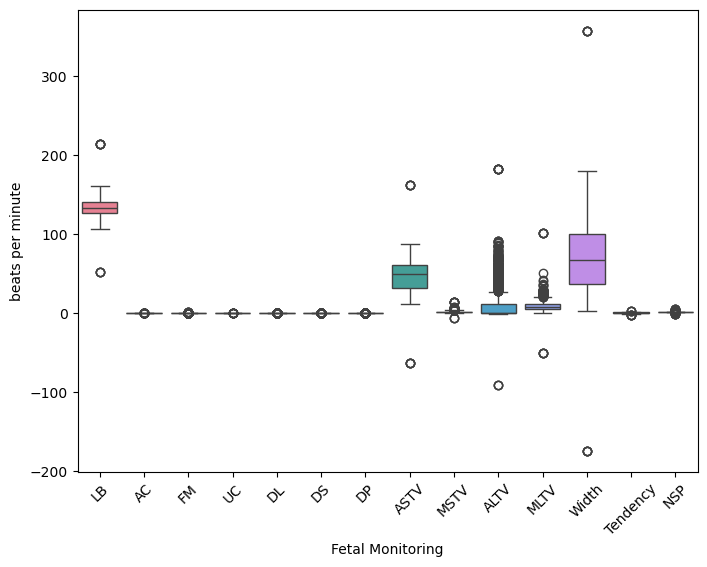

In [4]:
plt.figure(figsize=(8,6))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.xlabel("Fetal Monitoring")
plt.ylabel("beats per minute")
plt.show()


In [5]:
# user defined function to check outliers and replace with mean or median
def impute_missing_values_conditional(df):
    df_imputed = df.copy()
    
    # Iterate over all columns
    for column in df_imputed.columns:
        # Check if the column is numeric and has missing values
        if pd.api.types.is_numeric_dtype(df_imputed[column]) and df_imputed[column].isnull().any():
            # Get non-null values for outlier detection
            data = df_imputed[column].dropna()
            
            if not data.empty:
                # Calculate Q1, Q3, and IQR
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                
                # Define bounds for outliers
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                # Check for the presence of outliers
                has_outliers = ((data < lower_bound) | (data > upper_bound)).any()
                
                if has_outliers:
                    # Impute with median if outliers exist (median is robust to outliers)
                    fill_value = data.median()
                    print(f"Column '{column}': Outliers detected. Filling NaNs with median ({fill_value}).")
                else:
                    # Impute with mean if no outliers exist
                    fill_value = data.mean()
                    print(f"Column '{column}': No significant outliers. Filling NaNs with mean ({fill_value:.2f}).")
                
                df_imputed[column] = df_imputed[column].fillna(fill_value)
            else:
                print(f"Column '{column}' is empty after dropping NaNs. Cannot impute.")
                
    return df_imputed

df=impute_missing_values_conditional(df)
df

Column 'LB': Outliers detected. Filling NaNs with median (133.0).
Column 'AC': Outliers detected. Filling NaNs with median (0.001633991).
Column 'DS': Outliers detected. Filling NaNs with median (0.0).
Column 'DP': Outliers detected. Filling NaNs with median (0.0).
Column 'MLTV': Outliers detected. Filling NaNs with median (7.4).
Column 'Width': Outliers detected. Filling NaNs with median (67.0).
Column 'Tendency': Outliers detected. Filling NaNs with median (0.0).
Column 'NSP': Outliers detected. Filling NaNs with median (1.0).


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [7]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


## 2.	Statistical Summary:
- Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
- Highlight any interesting findings from this summary


In [8]:
mean=df.mean()  # get the mean of each variables
median=df.median()
std_dev=df.std()
q1=df.quantile(0.25)
q3=df.quantile(0.75)
iqr=q3-q1
min1=df.min()
max1=df.max()

stat_summary = pd.DataFrame({
    "Mean":mean,
    "Median":median,
    "Standard Deviation":std_dev,
    "IQR":iqr,
    "Min":min1,
    "Max":max1
})
stat_summary
    
    

,Mean,Median,Standard Deviation,IQR,Min,Max
LB,133.340204,133.000000,11.214379,14.000000,51.842487,214.000000
AC,0.003204,0.001634,0.004373,0.005606,-0.019284,0.038567
FM,0.009894,0.000000,0.067540,0.002567,-0.480634,0.961268
UC,0.004391,0.004484,0.003340,0.004685,-0.014925,0.030002
DL,0.001895,0.000000,0.003343,0.003289,-0.015393,0.030769
DS,0.000002,0.000000,0.000141,0.000000,-0.001353,0.002706
DP,0.000173,0.000000,0.000836,0.000000,-0.005348,0.010695
ASTV,46.995984,49.000000,18.813973,29.000000,-63.000000,162.000000
MSTV,1.364378,1.200000,1.173632,1.000000,-6.600000,13.800000
ALTV,10.285964,0.000000,21.205041,11.000000,-91.000000,182.000000


Alternatively, you could use the df.describe() function which provides the mean, standard deviation, and quartiles (25th, 50th, 75th percentiles) in a single summary table

In [9]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


**Highlight any interesting findings from this summary**

|Description|Min|Max|
| :--- | :---: |----|
|Beats per minute(FHR)| 	106 |	160|
|#Accelerations per second 	|0 	|0.019|
|#Fetal movement per second 	|0 	|0.481|
|#Uterine contractions per second 	|0 	|0.015|
|#Light decelerations per second 	|0 	|0.015|
|#Severe decelarations per second 	|0 	|0.001|
|#Prolonged decelerations per seconds 	|0 	|0.005|
|% of time w/ abnormal short-term variability 	|12 |87|
|Mean value of short-term variability 	|0.2 	|7|
|% of time w/ abnormal long-term variability 	|0 |	91|
|Mean value of long-term variability 	|0 	|50.7|

The normal baseline Fetal Heart Rate (FHR) is generally considered to be between 110 and 160 beats per minute (bpm)
- As per the mean value 133 is between 110 and 160. So all the observation are fetal wellbeing, showing good oxygenation and nervous system development.

In [10]:
print(f" There are {len(df[(df['LB'] < 106) | (df['LB'] > 170)])} observations which are not in the Normal range of 110 and 160")

 There are 10 observations which are not in the Normal range of 110 and 160


In [11]:
dc=['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV','MLTV', 'Width', 'Tendency']
dmin=[106,0,0,0,0,0,0,12,0.2,0,0,3,-1]
dmax=[160,0.019,0.481,0.015,0.015,0.001,0.005,87,7,91,50.7,180,1]
for index, value in enumerate(dc):
    #print(d1[index],d2[index])
    print(f" There are {len(df[(df[dc[index]] < dmin[index]) | (df[dc[index]] > dmax[index])])} observations of {dc[index]} which are not in the Normal range of {dmin[index]} and {dmax[index]}")



 There are 10 observations of LB which are not in the Normal range of 106 and 160
 There are 36 observations of AC which are not in the Normal range of 0 and 0.019
 There are 58 observations of FM which are not in the Normal range of 0 and 0.481
 There are 19 observations of UC which are not in the Normal range of 0 and 0.015
 There are 41 observations of DL which are not in the Normal range of 0 and 0.015
 There are 60 observations of DS which are not in the Normal range of 0 and 0.001
 There are 59 observations of DP which are not in the Normal range of 0 and 0.005
 There are 11 observations of ASTV which are not in the Normal range of 12 and 87
 There are 10 observations of MSTV which are not in the Normal range of 0.2 and 7
 There are 44 observations of ALTV which are not in the Normal range of 0 and 91
 There are 16 observations of MLTV which are not in the Normal range of 0 and 50.7
 There are 10 observations of Width which are not in the Normal range of 3 and 180
 There are 33 o

In [12]:
print(f"min:{df['NSP'].min()}, max:{df['NSP'].max()}")


min:-1.025988003, max:5.0


## Data Visualization:
- Create histograms or boxplots to visualize the distributions of various numerical variables.
- Use bar charts or pie charts to display the frequency of categories for categorical variables.
- Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
- Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.


### Create histograms or boxplots to visualize the distributions of various numerical variables.

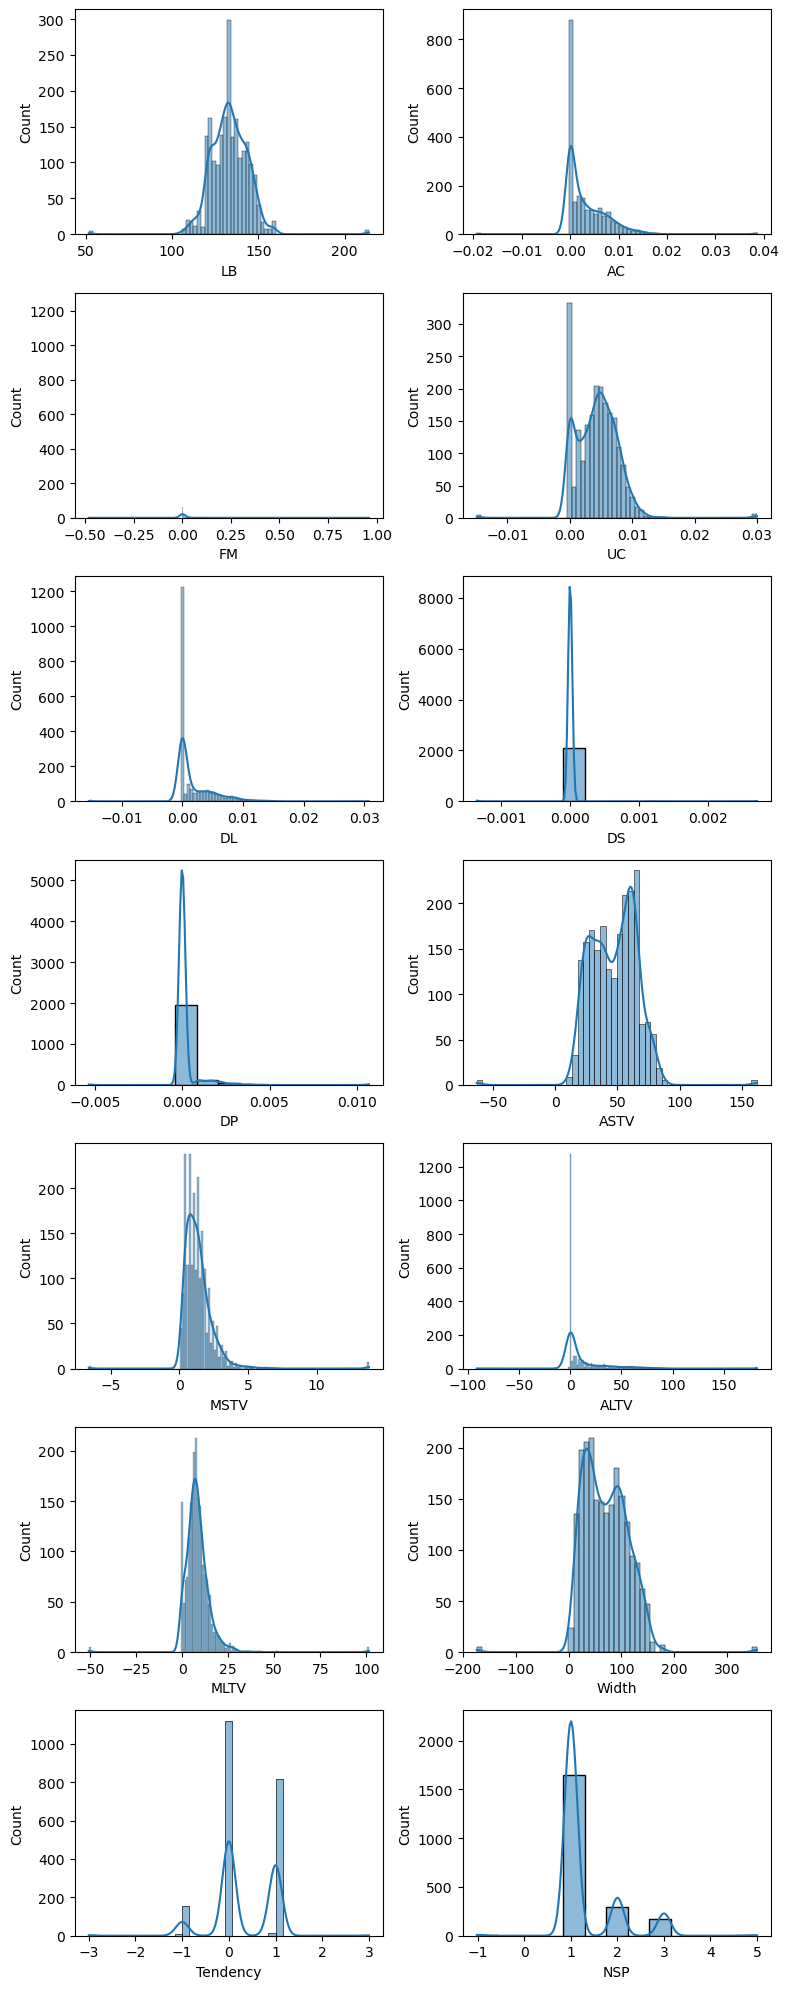

In [13]:
#df['LB'].plot(kind='hist',ked=True)
cols = df.columns
plt.figure(figsize=(8, 20))
for i,col in enumerate(cols):
    ax= plt.subplot(len(cols) // 2 + (len(cols) % 2), 2, i + 1) # Create subplots
    sns.histplot(data=df,x=col,kde=True)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


### Use bar charts or pie charts to display the frequency of categories for categorical variables.


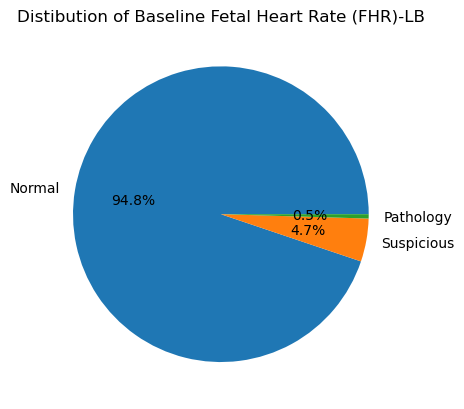

In [14]:
"""
Baseline
Normal --Between 110 and 150 bpm
Suspicious -- Between 100 and 110 bpm or between 150 and 170 bpm
Pathology --Below 100 or above 170 bpm
"""
df_extra =df
bins = [-np.inf, 100,110,150,170, np.inf] # -infinity to 100,110,150,170 to +infinity
labels = ['Pathology', 'Suspicious', 'Normal','Suspicious','Pathology']

df_extra['lb_category'] = pd.cut(df_extra['LB'], bins=bins, labels=labels, right=False,ordered=False)

lb_category= df_extra['lb_category'].value_counts()
lb_category.plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distibution of Baseline Fetal Heart Rate (FHR)-LB')
plt.savefig('pie_chart.png', bbox_inches='tight', dpi=300)

plt.show()

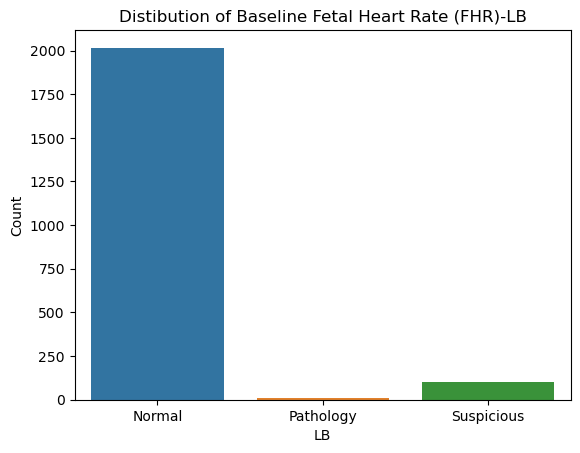

In [15]:
sns.countplot(x='lb_category', data=df,hue='lb_category')
plt.ylabel('Count')
plt.xlabel('LB')
plt.title('Distibution of Baseline Fetal Heart Rate (FHR)-LB')
plt.show()

### Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.

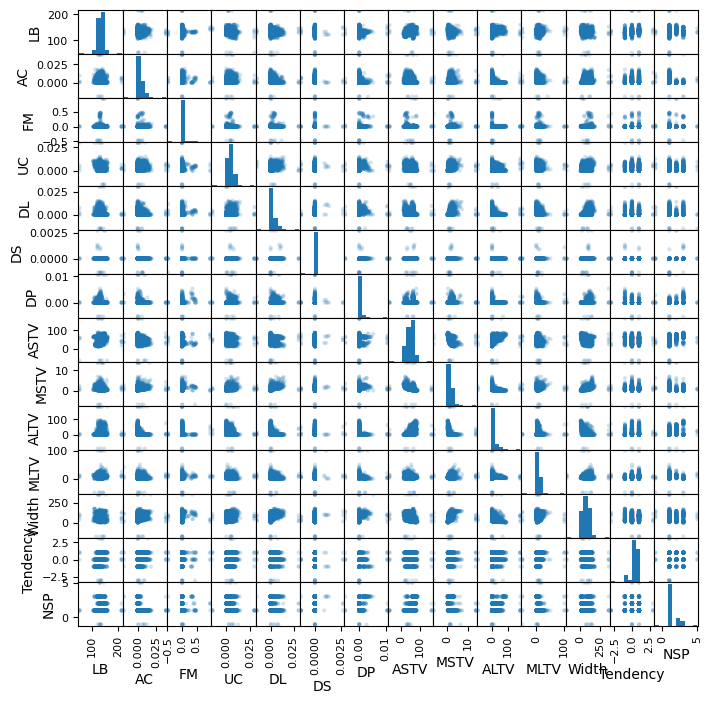

In [16]:
"""
plt.scatter(df['LB'],df['AC'])
plt.scatter(df['LB'],df['FM'])
plt.show()
"""
pd.plotting.scatter_matrix(df, alpha=0.2, figsize=(8, 8))
plt.show()

### Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

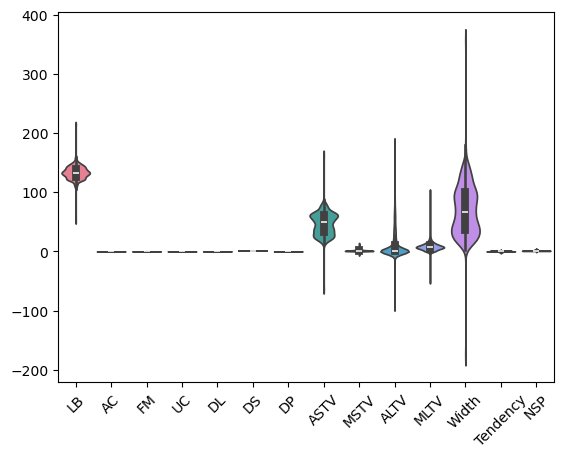

In [17]:
sns.violinplot(df)
plt.xticks(rotation=45)
plt.show()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   LB           2126 non-null   float64 
 1   AC           2126 non-null   float64 
 2   FM           2126 non-null   float64 
 3   UC           2126 non-null   float64 
 4   DL           2126 non-null   float64 
 5   DS           2126 non-null   float64 
 6   DP           2126 non-null   float64 
 7   ASTV         2126 non-null   float64 
 8   MSTV         2126 non-null   float64 
 9   ALTV         2126 non-null   float64 
 10  MLTV         2126 non-null   float64 
 11  Width        2126 non-null   float64 
 12  Tendency     2126 non-null   float64 
 13  NSP          2126 non-null   float64 
 14  lb_category  2126 non-null   category
dtypes: category(1), float64(14)
memory usage: 234.9 KB


## 4.	Pattern Recognition and Insights:

### Identify any correlations between variables and discuss their potential implications.

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP', 'lb_category'],
      dtype='object')


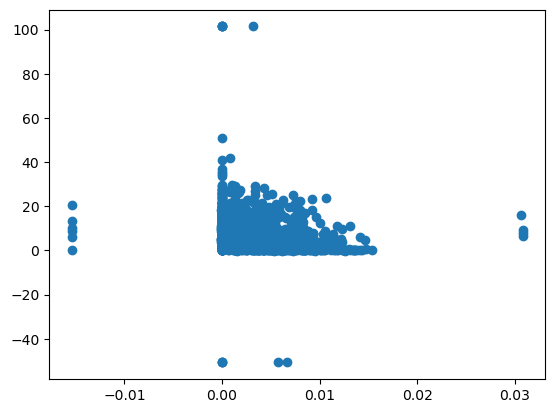

In [19]:
print(df.columns)
plt.scatter(x="DL",y="MLTV",data=df)
plt.savefig('relation.png', bbox_inches='tight', dpi=300)
plt.show()


In [20]:
## Look for trends or patterns over time if temporal data is available.

#### correlations between  DL and MLTV

There is a negative cooreation between  DL and MLTV

#### potential implications

**Recurrent Late Decelerations + Minimal/Absent LTV = High Risk:**\
Indicates urgent need for intervention (e.g., intrauterine resuscitation, delivery).\
**Recurrent Late Decelerations + Moderate LTV:**\
Still indicates uteroplacental insufficiency but may not indicate immediate, severe acidosis

## 5.	Conclusion:

### Summarize the key insights and patterns discovered through your exploratory analysis

Cardiotocography (CTG) is
a widely used, non-invasive, and continuous method for monitoring fetal well-being during the third trimester and throughout labor.\
It records the fetal heart rate (FHR) and uterine contractions (UC), allowing healthcare providers to assess how the fetus is responding to labor stress.

### Discuss how these findings could impact decision-making or further analyses

As per the Data , it is found that 94.8% for in normal conditions
4.7% are Suspicious and 0.5 Pathology

On the basis of findings, We can take necessary actions before any emergency happens in child birth